In [1]:
# Cell 0.1 - Mount Google Drive
from google.colab import drive
drive.mount('/gdrive', force_remount=False)

Mounted at /gdrive


In [2]:
# Cell 0.2 - List contents of MyDrive
import os

try:
    entries = os.listdir("/gdrive/MyDrive")
    print("Found", len(entries), "items in MyDrive. Showing first 50:")
    for i, name in enumerate(entries[:50], start=1):
        print(f"{i:02d}. {name}")
except Exception as e:
    print("Error listing /gdrive/MyDrive:", e)


Found 3 items in MyDrive. Showing first 50:
01. project_visual_search
02. visual_search_repo
03. Colab Notebooks


In [3]:
# Cell 0.3 - Detect project root
import glob

PROJECT_REL = "project_visual_search"
PREFERRED_PROJECT_DIRS = [
    f"/gdrive/MyDrive/{PROJECT_REL}",
    f"/content/drive/MyDrive/{PROJECT_REL}",
    f"/mnt_drive/MyDrive/{PROJECT_REL}",
    f"/content/{PROJECT_REL}",
]

def detect_project_root():
    for p in PREFERRED_PROJECT_DIRS:
        if os.path.exists(p):
            return os.path.abspath(p)
    candidates = glob.glob(f"/gdrive/**/{PROJECT_REL}", recursive=True) \
               + glob.glob(f"/content/**/{PROJECT_REL}", recursive=True)
    if candidates:
        return os.path.abspath(candidates[0])
    return None

project_root = detect_project_root()
print("Project root detected at:", project_root if project_root else "❌ NOT FOUND")


Project root detected at: /gdrive/MyDrive/project_visual_search


In [4]:
# Cell 0.4 - Find Stage-1 manifest and list key project folders (run this after mount detection)
import os, glob, textwrap

PROJECT_ROOT = "/gdrive/MyDrive/project_visual_search"

print("Project root:", PROJECT_ROOT)
print()

# Look for manifest candidates
manifest_candidates = glob.glob(os.path.join(PROJECT_ROOT, "*manifest*.*")) + \
                      glob.glob(os.path.join(PROJECT_ROOT, "data", "**", "*manifest*.*"), recursive=True)
manifest_candidates = sorted(set(manifest_candidates))
if manifest_candidates:
    print("Found manifest candidate(s):")
    for m in manifest_candidates:
        print(" -", m)
else:
    print("No manifest file found in project root or data/ (looking for *manifest*.*).")

# Check key folders
folders = {
    "raw_dir": os.path.join(PROJECT_ROOT, "data", "raw"),
    "annotations_dir": os.path.join(PROJECT_ROOT, "data", "annotations"),
    "thumbs_dir": os.path.join(PROJECT_ROOT, "data", "thumbs"),
    "processed_dir": os.path.join(PROJECT_ROOT, "data", "processed"),
    "repo_dir": os.path.join(PROJECT_ROOT, "project_visual_search_repo"),
}

print("\nKey folder checks:")
for k, p in folders.items():
    exists = os.path.exists(p)
    print(f"  {k:14}: {p} ->", "OK" if exists else "MISSING")

# If raw_dir exists, show a short sample listing (depth 2)
raw_dir = folders["raw_dir"]
if os.path.exists(raw_dir):
    print("\nSample files under data/raw (up to 50 entries, recursive depth 2):")
    sample = []
    for root, dirs, files in os.walk(raw_dir):
        for fname in files[:200]:
            sample.append(os.path.join(root, fname))
        # limit to a few directories
        if len(sample) >= 50:
            break
    for i, f in enumerate(sample[:50], start=1):
        print(f"{i:03d}. {os.path.relpath(f, PROJECT_ROOT)}")
else:
    print("\nNo raw_dir to sample.")

print("\nIf manifest is missing, check where Stage-1 outputs were stored and move the manifest CSV/Parquet to the project root or data folder.")


Project root: /gdrive/MyDrive/project_visual_search

Found manifest candidate(s):
 - /gdrive/MyDrive/project_visual_search/data/raw_image_first_manifest.csv
 - /gdrive/MyDrive/project_visual_search/data/raw_image_first_manifest_enhanced.csv
 - /gdrive/MyDrive/project_visual_search/data/raw_image_first_manifest_enhanced.parquet

Key folder checks:
  raw_dir       : /gdrive/MyDrive/project_visual_search/data/raw -> OK
  annotations_dir: /gdrive/MyDrive/project_visual_search/data/annotations -> OK
  thumbs_dir    : /gdrive/MyDrive/project_visual_search/data/thumbs -> OK
  processed_dir : /gdrive/MyDrive/project_visual_search/data/processed -> OK
  repo_dir      : /gdrive/MyDrive/project_visual_search/project_visual_search_repo -> MISSING

Sample files under data/raw (up to 50 entries, recursive depth 2):
001. data/raw/development-set/GC01PS03D0217.tif
002. data/raw/development-set/GC01PS03D0038.tif
003. data/raw/development-set/GC01PS03D0062.tif
004. data/raw/development-set/GC01PS03D0155

In [5]:
# Cell 0.5 - Load Stage-1 manifest and print summary (fixed version)
# Test-only outputs will go into /test subfolder

import os
import pandas as pd

PROJECT_ROOT = "/gdrive/MyDrive/project_visual_search"
TEST_DIR = os.path.join(PROJECT_ROOT, "test")
os.makedirs(TEST_DIR, exist_ok=True)

# Prefer the enhanced parquet if present
candidates = [
    os.path.join(PROJECT_ROOT, "data", "raw_image_first_manifest_enhanced.parquet"),
    os.path.join(PROJECT_ROOT, "data", "raw_image_first_manifest_enhanced.csv"),
    os.path.join(PROJECT_ROOT, "data", "raw_image_first_manifest.parquet"),
    os.path.join(PROJECT_ROOT, "data", "raw_image_first_manifest.csv"),
]

manifest_path = None
for p in candidates:
    if os.path.exists(p):
        manifest_path = p
        break
# fallback: search for any manifest-like file under project root
if manifest_path is None:
    import glob
    found = glob.glob(os.path.join(PROJECT_ROOT, "**", "*manifest*.*"), recursive=True)
    if found:
        pq = [f for f in found if f.lower().endswith(".parquet")]
        manifest_path = pq[0] if pq else found[0]

if manifest_path is None:
    raise FileNotFoundError("No manifest found under project root. Please ensure Stage-1 manifest exists.")

print("Manifest found at:", manifest_path)

# Load manifest
if manifest_path.lower().endswith(".parquet"):
    df = pd.read_parquet(manifest_path)
else:
    df = pd.read_csv(manifest_path)

print("\nLoaded manifest: rows =", len(df), "columns =", len(df.columns))
print("Columns:", list(df.columns))

# Helper for safe stats
def safe_stats(series):
    s = series.dropna()
    if s.empty:
        return None
    try:
        return {
            "min": float(s.min()),
            "median": float(s.median()),
            "max": float(s.max()),
            "mean": float(s.mean()),
            "std": float(s.std())
        }
    except Exception:
        return {"unique_count": int(s.nunique())}

# Dataset splits
print("\n-- Dataset splits (if 'set' exists) --")
if 'set' in df.columns:
    print(df['set'].value_counts(dropna=False))
else:
    print("No 'set' column found in manifest.")

# Bands info
if 'bands' in df.columns:
    print("\nBands column present. Distribution:")
    print(df['bands'].value_counts().sort_index())
    print(f"Images with >=4 bands: {(df['bands'] >= 4).sum()} / {len(df)}")
else:
    print("\nNo 'bands' column in manifest.")

# Width/Height stats
print("\n-- Spatial dimensions --")
for col in ['width', 'height']:
    if col in df.columns:
        st = safe_stats(df[col])
        if st:
            print(f"{col}: min={st['min']}, median={st['median']}, max={st['max']}, mean={st['mean']:.1f}, std={st['std']:.1f}")
    else:
        print(f"{col}: not present")

# Cloud and nodata related
for col in ['cloud_score', 'percent_nodata', 'percent_zero']:
    if col in df.columns:
        st = safe_stats(df[col])
        if st and 'min' in st:
            print(f"{col}: min={st['min']}, median={st['median']}, max={st['max']}, mean={st['mean']:.3f}, std={st['std']:.3f}")
        else:
            print(f"{col}: {st}")
    else:
        print(f"{col}: not present")

# dtype and filesize
if 'dtype' in df.columns:
    print("\nDtype distribution:")
    print(df['dtype'].value_counts().head(10))
if 'filesize_mb' in df.columns:
    st = safe_stats(df['filesize_mb'])
    print("\nFilesize (MB) stats:", st)

# Sample filenames
print("\nSample filenames (10):")
if 'filename' in df.columns:
    sample_fns = df['filename'].sample(min(10, len(df))).tolist()
    for fn in sample_fns:
        print(" -", fn)

# Top 10 largest images
if 'width' in df.columns and 'height' in df.columns:
    df['area'] = df['width'].fillna(0).astype(int) * df['height'].fillna(0).astype(int)
    top10 = df.sort_values('area', ascending=False).head(10)
    print("\nTop 10 largest images (by pixels):")
    for _, row in top10.iterrows():
        fn = row.get('filename','<no-filename>')
        print(f" - {fn}: {int(row['width'])} x {int(row['height'])} (area={int(row['area']):,})")

# Save preview to test folder
preview_path = os.path.join(TEST_DIR, "manifest_preview_stage2.csv")
df.head(200).to_csv(preview_path, index=False)
print(f"\nWrote preview of first 200 manifest rows to TEST folder: {preview_path}")

print("\nCell 0.5 complete.")


Manifest found at: /gdrive/MyDrive/project_visual_search/data/raw_image_first_manifest_enhanced.parquet

Loaded manifest: rows = 402 columns = 19
Columns: ['filename', 'set', 'width', 'height', 'bands', 'crs', 'dtype', 'nodata', 'percent_nodata', 'sample_min', 'sample_max', 'sample_mean', 'thumb', 'status', 'filesize_mb', 'has_pair', 'sample_std', 'percent_zero', 'cloud_score']

-- Dataset splits (if 'set' exists) --
set
development-set     300
mock-dataset-tif     80
sample-set           22
Name: count, dtype: int64

Bands column present. Distribution:
bands
4    402
Name: count, dtype: int64
Images with >=4 bands: 402 / 402

-- Spatial dimensions --
width: min=740.0, median=1910.0, max=4659.0, mean=2033.5, std=481.3
height: min=504.0, median=1571.0, max=7530.0, mean=1779.0, std=936.6
cloud_score: min=2.094, median=4.452500000000001, max=41.569, mean=6.837, std=6.108
percent_nodata: min=0.0, median=0.0, max=26.38, mean=1.425, std=2.549
percent_zero: {'unique_count': 306}

Dtype distri

In [6]:
#cell 1.1

import os
import json
import math
import random
import shutil
import glob
from datetime import datetime

import pandas as pd

# --- Project paths (adjust if your project root differs) ---
PROJECT_ROOT = "/gdrive/MyDrive/project_visual_search"
TEST_DIR = os.path.join(PROJECT_ROOT, "test")
PROC_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
TILES_DIR = os.path.join(PROC_DIR, "tiles")
SAMPLE_TILES_DIR = os.path.join(TILES_DIR, "sample_run")
TMP_DIR = os.path.join(PROC_DIR, "tmp")

os.makedirs(TEST_DIR, exist_ok=True)
os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(TILES_DIR, exist_ok=True)
os.makedirs(SAMPLE_TILES_DIR, exist_ok=True)
os.makedirs(TMP_DIR, exist_ok=True)

# --- Load manifest (prefer enhanced parquet) ---
manifest_candidates = [
    os.path.join(PROJECT_ROOT, "data", "raw_image_first_manifest_enhanced.parquet"),
    os.path.join(PROJECT_ROOT, "data", "raw_image_first_manifest_enhanced.csv"),
    os.path.join(PROJECT_ROOT, "data", "raw_image_first_manifest.parquet"),
    os.path.join(PROJECT_ROOT, "data", "raw_image_first_manifest.csv"),
]
manifest_path = None
for p in manifest_candidates:
    if os.path.exists(p):
        manifest_path = p
        break
if manifest_path is None:
    # fallback search
    found = glob.glob(os.path.join(PROJECT_ROOT, "**", "*manifest*.*"), recursive=True)
    manifest_path = found[0] if found else None

if manifest_path is None:
    raise FileNotFoundError("Stage-1 manifest not found. Place the manifest in project root or data/ and re-run this cell.")

if manifest_path.lower().endswith(".parquet"):
    df = pd.read_parquet(manifest_path)
else:
    df = pd.read_csv(manifest_path)

# --- Your chosen config (Option B) ---
processing_params = {
    "strategy": "B_downcast_uint8_dual",
    "band_policy": "dual",                      # keep 4-band but downcast to uint8 after p2-p98 scale
    "tile_size": 512,
    "stride": 384,
    "percentile_pmin": 2,
    "percentile_pmax": 98,
    "nodata_drop_threshold_pct": 90,
    "cloud_flagging": True,
    "edge_handling": "partial_tiles_as_is",
    "thumbnail_size": [128, 128],
    "thumbnail_per_tile": True,
    "save_full_jpeg_preview": False,            # we will NOT save full-res JPEG previews to save space
    "save_geotiff_uint8": True,
    "sample_plan": "sample-set + 20 dev + 20 mock",
    "sample_dev_count": 20,
    "sample_mock_count": 20,
    "created_at": datetime.utcnow().isoformat() + "Z"
}

# persist params to project root
params_out = os.path.join(PROJECT_ROOT, "processing_params_stage2.json")
with open(params_out, "w") as f:
    json.dump(processing_params, f, indent=2)
print("Saved processing params to:", params_out)

# --- Build sample lists ---
if 'set' not in df.columns or 'filename' not in df.columns:
    raise ValueError("Manifest must contain 'set' and 'filename' columns.")

sample_set_df = df[df['set'] == 'sample-set'].copy()
dev_df = df[df['set'] == 'development-set'].copy()
mock_df = df[df['set'] == 'mock-dataset-tif'].copy()

# determine exact sample selections
sample_filenames = sample_set_df['filename'].tolist()
# if sample_set has fewer entries than expected, it's okay – we'll use all
dev_sample_n = min(processing_params['sample_dev_count'], len(dev_df))
mock_sample_n = min(processing_params['sample_mock_count'], len(mock_df))

random.seed(42)
dev_sample_rows = dev_df.sample(dev_sample_n, random_state=42) if dev_sample_n > 0 else dev_df.head(0)
mock_sample_rows = mock_df.sample(mock_sample_n, random_state=42) if mock_sample_n > 0 else mock_df.head(0)

# final sample list (relative paths from manifest)
sample_list = list(sample_filenames) + dev_sample_rows['filename'].tolist() + mock_sample_rows['filename'].tolist()

# save sample list to test folder
sample_list_path = os.path.join(TEST_DIR, "sample_run_filelist.csv")
pd.DataFrame({"filename": sample_list}).to_csv(sample_list_path, index=False)
print("Wrote sample filelist (for sample run) to:", sample_list_path)
print(f"  total sample images: {len(sample_list)} (sample-set: {len(sample_filenames)}, dev: {len(dev_sample_rows)}, mock: {len(mock_sample_rows)})")

# --- Estimate tile counts for this sample selection ---
def estimate_tiles_for_image(width, height, tile_size=512, stride=384):
    if width <= 0 or height <= 0:
        return 0
    nx = max(1, math.ceil((width - tile_size) / stride) + 1) if width > tile_size else 1
    ny = max(1, math.ceil((height - tile_size) / stride) + 1) if height > tile_size else 1
    return nx * ny

# subset manifest rows that are in sample_list
df_sample = df[df['filename'].isin(sample_list)].copy()
df_sample['est_tiles'] = df_sample.apply(lambda r: estimate_tiles_for_image(r['width'], r['height']), axis=1)
sample_tiles_total = int(df_sample['est_tiles'].sum())

print("\nEstimated tiles for sample run:", sample_tiles_total)
print("Breakdown by set in sample:")
for s, g in df_sample.groupby('set'):
    print(f"  {s}: {int(g['est_tiles'].sum()):,} tiles ({len(g)} images)")

# --- Storage estimate for sample run with downcast-to-uint8 GeoTIFF + thumbnails ---
# heuristics for per-tile sizes (conservative ranges)
GTIFF_UINT8_MB_RANGE = (0.4, 1.2)   # per-tile compressed 4-band uint8 GeoTIFF (estimate)
THUMB_JPEG_MB_RANGE   = (0.01, 0.03) # thumbnail 128x128 JPEG per tile

min_mb = sample_tiles_total * (GTIFF_UINT8_MB_RANGE[0] + THUMB_JPEG_MB_RANGE[0])
max_mb = sample_tiles_total * (GTIFF_UINT8_MB_RANGE[1] + THUMB_JPEG_MB_RANGE[1])

min_gb = min_mb / 1024.0
max_gb = max_mb / 1024.0

print(f"\nEstimated storage for sample run (downcast uint8 GeoTIFF + thumbnail): {min_gb:.2f} GB — {max_gb:.2f} GB")

# check free space on project root
try:
    total, used, free = shutil.disk_usage(PROJECT_ROOT)
    free_gb = free / (1024**3)
    print(f"Free space available: {free_gb:.2f} GB")
    if free_gb < min_gb * 1.05:
        print("⚠️ WARNING: free space may be low for this sample run. Consider reducing sample size or freeing Drive space.")
except Exception as e:
    print("Could not determine free disk space:", e)

# write small sample manifest preview in test for reference
df_sample[['filename','set','width','height','est_tiles']].to_csv(os.path.join(TEST_DIR, "sample_run_manifest_preview.csv"), index=False)
print("\nWrote sample_run_manifest_preview.csv to test folder.")

print("\nCell 0.7 complete. Next: I will provide the sample-tiling worker cell which will process each image from the sample filelist, create per-tile downcasted uint8 4-band GeoTIFFs + 128x128 thumbnails, and write a tiles_manifest_sample.parquet in the test folder. Run that only after you confirm free space looks OK.")


/tmp/ipython-input-1578015616.py:68: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.utcnow().isoformat() + "Z"


Saved processing params to: /gdrive/MyDrive/project_visual_search/processing_params_stage2.json
Wrote sample filelist (for sample run) to: /gdrive/MyDrive/project_visual_search/test/sample_run_filelist.csv
  total sample images: 62 (sample-set: 22, dev: 20, mock: 20)

Estimated tiles for sample run: 2027
Breakdown by set in sample:
  development-set: 635 tiles (20 images)
  mock-dataset-tif: 598 tiles (20 images)
  sample-set: 794 tiles (22 images)

Estimated storage for sample run (downcast uint8 GeoTIFF + thumbnail): 0.81 GB — 2.43 GB
Free space available: 8.81 GB

Wrote sample_run_manifest_preview.csv to test folder.

Cell 0.7 complete. Next: I will provide the sample-tiling worker cell which will process each image from the sample filelist, create per-tile downcasted uint8 4-band GeoTIFFs + 128x128 thumbnails, and write a tiles_manifest_sample.parquet in the test folder. Run that only after you confirm free space looks OK.


In [7]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 84.0 MB/s eta 0:00:00


In [1]:
# Cell 1.2 - Prepare full parent_paths (402 images, TIFFs preferred)
# Purpose: Load manifest, resolve full paths (prefer TIFF if both TIF/JPG exist), ready for tiling.

import os
import pandas as pd
from pathlib import Path

PROJECT_ROOT = "/gdrive/MyDrive/project_visual_search"

# Load Stage-1 manifest
MANIFEST_PATH = os.path.join(PROJECT_ROOT, "data", "raw_image_first_manifest_enhanced.parquet")
df_full = pd.read_parquet(MANIFEST_PATH)

# All 402 entries
parent_filenames = df_full['filename'].tolist()
print(f"Loaded full manifest with {len(parent_filenames)} entries.")

# Prefer TIFF when resolving
def resolve_prefer_tif(fn):
    raw_root = os.path.join(PROJECT_ROOT, "data", "raw")
    cand_direct = os.path.join(raw_root, fn)
    if os.path.exists(cand_direct) and cand_direct.lower().endswith(('.tif', '.tiff')):
        return cand_direct
    if fn.lower().endswith(('.jpg', '.jpeg')):
        base = os.path.splitext(fn)[0]
        cand = os.path.join(raw_root, base + ".tif")
        if os.path.exists(cand):
            return cand
    found = list(Path(raw_root).rglob(os.path.basename(fn)))
    if found:
        for f in found:
            if str(f).lower().endswith(('.tif', '.tiff')):
                return str(f)
        return str(found[0])
    return cand_direct

parent_paths = [resolve_prefer_tif(fn) for fn in parent_filenames]
print(f"Resolved {len(parent_paths)} parent paths (TIFFs preferred).")

# Keep in globals for Cell 1.3
globals()["parent_paths"] = parent_paths


Loaded full manifest with 402 entries.
Resolved 402 parent paths (TIFFs preferred).


In [2]:
# Cell 1.3 - Full dataset tiling (402 parents) in safe batches
# Purpose: Process all parent images into 512x512 tiles with overlap,
# normalize, save uint8 GeoTIFF tiles + JPEG thumbnails,
# and write parquet manifests in parts (resumable if interrupted).

import os, glob, json, time, shutil
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
import rasterio
from rasterio.windows import Window
from rasterio.crs import CRS
from rasterio.windows import transform as win_transform

# Project paths
PROJECT_ROOT = "/gdrive/MyDrive/project_visual_search"
TEST_DIR = os.path.join(PROJECT_ROOT, "test")
PARTS_DIR = os.path.join(TEST_DIR, "tiles_manifest_parts")
PARAMS_PATH = os.path.join(PROJECT_ROOT, "processing_params_stage2.json")
ERROR_LOG = os.path.join(TEST_DIR, "tiling_errors.log")

os.makedirs(PARTS_DIR, exist_ok=True)

# Load tiling params
with open(PARAMS_PATH, "r") as f:
    params = json.load(f)
TILE_SIZE = int(params.get("tile_size", 512))
STRIDE = int(params.get("stride", 384))  # 25% overlap
P2 = float(params.get("percentile_pmin", 2.0))
P98 = float(params.get("percentile_pmax", 98.0))
NODATA_DROP_PCT = float(params.get("nodata_drop_threshold_pct", 90.0))
THUMB_SIZE = tuple(params.get("thumbnail_size", [128,128]))

OUT_TILES_BASE = os.path.join(PROJECT_ROOT, "data", "processed", "tiles")
THUMB_DIR = os.path.join(TEST_DIR, "thumbnails_batched")
os.makedirs(OUT_TILES_BASE, exist_ok=True)
os.makedirs(THUMB_DIR, exist_ok=True)

# Confirm parent list
if "parent_paths" not in globals() or not parent_paths:
    raise RuntimeError("parent_paths not found; run Cell 1.2 first.")
print("Total parents to process:", len(parent_paths))

# Helpers
def percentile_scale(arr, pmin=P2, pmax=P98, eps=1e-6):
    out = np.zeros_like(arr, dtype=np.float32)
    pmins=[]; pmaxs=[]
    for b in range(arr.shape[0]):
        band = arr[b].astype(np.float32)
        lo = np.percentile(band, pmin); hi = np.percentile(band, pmax)
        scaled = (band - lo) / (hi - lo + eps)
        scaled = np.clip(scaled, 0.0, 1.0)
        out[b] = scaled; pmins.append(float(lo)); pmaxs.append(float(hi))
    return out, pmins, pmaxs

def save_geotiff_uint8_safe(path, arr_uint8, transform=None, crs_input=None):
    profile = {"driver":"GTiff","height":arr_uint8.shape[1],"width":arr_uint8.shape[2],
               "count":arr_uint8.shape[0],"dtype":"uint8","compress":"DEFLATE","predictor":2}
    if crs_input is not None:
        try: profile["crs"] = CRS.from_user_input(crs_input)
        except Exception: pass
    if transform is not None:
        profile["transform"] = transform
    with rasterio.open(path,"w",**profile) as dst: dst.write(arr_uint8)

def save_thumbnail_jpeg(path, rgb_uint8_arr):
    img = Image.fromarray(rgb_uint8_arr); img=img.convert("RGB")
    img=img.resize(THUMB_SIZE, Image.BILINEAR); img.save(path, "JPEG", quality=85)

def compute_pct_nodata(arr, nodata_val):
    if nodata_val is not None:
        mask = np.any([arr[b]==nodata_val for b in range(arr.shape[0])], axis=0)
    else:
        mask = np.any(np.isnan(arr), axis=0)
    return float(np.sum(mask)/mask.size)*100.0

# Detect already processed parents
processed_parents = set()
for pf in sorted(glob.glob(os.path.join(PARTS_DIR, "tiles_part_*.parquet"))):
    try:
        d = pd.read_parquet(pf, columns=['parent_image'])
        processed_parents.update(d['parent_image'].unique().tolist())
    except Exception:
        continue

parents_to_process = [p for p in parent_paths if os.path.relpath(p, PROJECT_ROOT) not in processed_parents]
print("Parents remaining to process:", len(parents_to_process))

# Batch loop
BATCH_SIZE = 20
part_index = len(sorted(glob.glob(os.path.join(PARTS_DIR, "tiles_part_*.parquet")))) + 1
total_batches = (len(parents_to_process)+BATCH_SIZE-1)//BATCH_SIZE
print(f"Total batches to run: {total_batches} (batch size: {BATCH_SIZE})")

for i in range(0, len(parents_to_process), BATCH_SIZE):
    batch = parents_to_process[i:i+BATCH_SIZE]
    batch_rows = []
    print(f"\n=== Starting batch {(i//BATCH_SIZE)+1}/{total_batches} ===")
    for p in tqdm(batch):
        if not os.path.exists(p):
            with open(ERROR_LOG,"a") as ef: ef.write(f"Missing parent: {p}\n"); continue
        rel_parent = os.path.relpath(p, PROJECT_ROOT)
        try:
            with rasterio.open(p) as src:
                nodata_val = src.nodata; transform = src.transform; bands_count = src.count
                band_indices = list(range(1, bands_count+1)); W=src.width; H=src.height
                y=0
                while y < H:
                    x=0
                    h_win = TILE_SIZE if y+TILE_SIZE<=H else H-y
                    while x < W:
                        w_win = TILE_SIZE if x+TILE_SIZE<=W else W-x
                        window = Window(col_off=x, row_off=y, width=w_win, height=h_win)
                        arr = src.read(band_indices, window=window)
                        pct_nodata = compute_pct_nodata(arr, nodata_val)
                        if pct_nodata > NODATA_DROP_PCT:
                            x += STRIDE; continue
                        scaled, pmins, pmaxs = percentile_scale(arr)
                        arr_uint8 = (scaled*255.0).round().astype(np.uint8)
                        rgb = np.stack([arr_uint8[2], arr_uint8[1], arr_uint8[0]], axis=-1) if arr_uint8.shape[0]>=3 else np.stack([arr_uint8[0]]*3, axis=-1)
                        parent_basename = os.path.splitext(os.path.basename(p))[0]
                        out_parent_dir = os.path.join(OUT_TILES_BASE, parent_basename); os.makedirs(out_parent_dir, exist_ok=True)
                        tile_name = f"{parent_basename}_x{x:06d}_y{y:06d}.tif"; tile_path = os.path.join(out_parent_dir, tile_name)
                        thumb_name = f"{parent_basename}_x{x:06d}_y{y:06d}.jpg"; thumb_path = os.path.join(THUMB_DIR, thumb_name)
                        try: tile_transform = win_transform(window, transform) if transform is not None else None
                        except Exception: tile_transform = None
                        save_geotiff_uint8_safe(tile_path, arr_uint8, transform=tile_transform, crs_input=src.crs)
                        save_thumbnail_jpeg(thumb_path, rgb)
                        mean_per_band = [float(np.mean(arr_uint8[b])) for b in range(arr_uint8.shape[0])]
                        std_per_band = [float(np.std(arr_uint8[b])) for b in range(arr_uint8.shape[0])]
                        pct_zero = float(np.sum(arr_uint8==0)/arr_uint8.size)*100.0
                        batch_rows.append({
                            "tile_id": os.path.splitext(tile_name)[0],
                            "parent_image": rel_parent,
                            "tile_path_tif": os.path.relpath(tile_path, PROJECT_ROOT),
                            "tile_path_thumb": os.path.relpath(thumb_path, PROJECT_ROOT),
                            "x_off": int(x),"y_off": int(y),"tile_w": int(w_win),"tile_h": int(h_win),
                            "pct_nodata": float(pct_nodata),"pct_zero": float(pct_zero),
                            "mean_per_band": mean_per_band,"std_per_band": std_per_band,
                            "norm_p2": pmins,"norm_p98": pmaxs,"bands": int(arr_uint8.shape[0]),
                            "dtype": "uint8","crs": str(src.crs) if src.crs else None,
                            "transform": tuple(tile_transform) if tile_transform is not None else None
                        })
                        x += STRIDE
                    y += STRIDE
        except Exception as e:
            with open(ERROR_LOG,"a") as ef: ef.write(f"Error processing {p}: {e}\n")
            continue

    # Write batch manifest part
    part_path = os.path.join(PARTS_DIR, f"tiles_part_{part_index:04d}.parquet")
    if batch_rows:
        pd.DataFrame(batch_rows).to_parquet(part_path, index=False)
        print(f"Wrote batch part manifest: {part_path} (rows: {len(batch_rows)})")
        part_index += 1
    else:
        print("No tiles produced for this batch.")

    # Disk usage check
    total, used, free = shutil.disk_usage(PROJECT_ROOT)
    print(f"Disk free after batch: {free/(1024**3):.2f} GB")

    time.sleep(2)

print("\n=== Full tiling run complete (or paused). Parts saved in:", PARTS_DIR)


Total parents to process: 402
Parents remaining to process: 102
Total batches to run: 6 (batch size: 20)

=== Starting batch 1/6 ===


  0%|          | 0/20 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(
100%|██████████| 20/20 [01:08<00:00,  3.42s/it]


Wrote batch part manifest: /gdrive/MyDrive/project_visual_search/test/tiles_manifest_parts/tiles_part_0016.parquet (rows: 576)
Disk free after batch: 8.75 GB

=== Starting batch 2/6 ===


100%|██████████| 20/20 [01:53<00:00,  5.69s/it]


Wrote batch part manifest: /gdrive/MyDrive/project_visual_search/test/tiles_manifest_parts/tiles_part_0017.parquet (rows: 954)
Disk free after batch: 9.06 GB

=== Starting batch 3/6 ===


...

Wrote batch part manifest: /gdrive/MyDrive/project_visual_search/test/tiles_manifest_parts/tiles_part_0019.parquet (rows: 490)
Disk free after batch: 8.80 GB

=== Starting batch 5/6 ===


100%|██████████| 20/20 [01:42<00:00,  5.10s/it]


Wrote batch part manifest: /gdrive/MyDrive/project_visual_search/test/tiles_manifest_parts/tiles_part_0020.parquet (rows: 806)
Disk free after batch: 8.53 GB

=== Starting batch 6/6 ===


100%|██████████| 2/2 [00:08<00:00,  4.22s/it]


Wrote batch part manifest: /gdrive/MyDrive/project_visual_search/test/tiles_manifest_parts/tiles_part_0021.parquet (rows: 60)
Disk free after batch: 8.53 GB

=== Full tiling run complete (or paused). Parts saved in: /gdrive/MyDrive/project_visual_search/test/tiles_manifest_parts


In [3]:
# Cell 1.4 - Merge all parquet part manifests into final tiles manifest
# Purpose: Concatenate part manifests from tiling into a single file for Stage-2 outputs.

import os
import glob
import pandas as pd

PROJECT_ROOT = "/gdrive/MyDrive/project_visual_search"
TEST_DIR = os.path.join(PROJECT_ROOT, "test")
PARTS_DIR = os.path.join(TEST_DIR, "tiles_manifest_parts")
FINAL_MANIFEST = os.path.join(TEST_DIR, "tiles_manifest_full.parquet")

# Gather all part files
part_files = sorted(glob.glob(os.path.join(PARTS_DIR, "tiles_part_*.parquet")))
print(f"Found {len(part_files)} part files.")

# Concatenate
dfs = []
for pf in part_files:
    try:
        dfs.append(pd.read_parquet(pf))
        print(f"Loaded {pf} ({len(dfs[-1])} rows)")
    except Exception as e:
        print(f"❌ Error reading {pf}: {e}")

if dfs:
    df_all = pd.concat(dfs, ignore_index=True)
    print(f"\nFinal merged manifest: {len(df_all)} rows, {df_all['parent_image'].nunique()} unique parents")
    df_all.to_parquet(FINAL_MANIFEST, index=False)
    print(f"✅ Wrote merged manifest to: {FINAL_MANIFEST}")
else:
    print("⚠️ No part files found, nothing merged.")


Found 21 part files.
Loaded /gdrive/MyDrive/project_visual_search/test/tiles_manifest_parts/tiles_part_0001.parquet (532 rows)
Loaded /gdrive/MyDrive/project_visual_search/test/tiles_manifest_parts/tiles_part_0002.parquet (508 rows)
Loaded /gdrive/MyDrive/project_visual_search/test/tiles_manifest_parts/tiles_part_0003.parquet (524 rows)
Loaded /gdrive/MyDrive/project_visual_search/test/tiles_manifest_parts/tiles_part_0004.parquet (936 rows)
Loaded /gdrive/MyDrive/project_visual_search/test/tiles_manifest_parts/tiles_part_0005.parquet (494 rows)
Loaded /gdrive/MyDrive/project_visual_search/test/tiles_manifest_parts/tiles_part_0006.parquet (490 rows)
Loaded /gdrive/MyDrive/project_visual_search/test/tiles_manifest_parts/tiles_part_0007.parquet (484 rows)
Loaded /gdrive/MyDrive/project_visual_search/test/tiles_manifest_parts/tiles_part_0008.parquet (1036 rows)
Loaded /gdrive/MyDrive/project_visual_search/test/tiles_manifest_parts/tiles_part_0009.parquet (540 rows)
Loaded /gdrive/MyDrive/p

In [5]:
# Cell 1.5 - Validate merged tiles manifest (fixed version)
# Purpose: Confirm number of tiles, per-parent distribution, and preview samples.

import pandas as pd

FINAL_MANIFEST = "/gdrive/MyDrive/project_visual_search/test/tiles_manifest_full.parquet"
df_tiles = pd.read_parquet(FINAL_MANIFEST)

print(f"Tiles manifest loaded: {len(df_tiles)} rows")
print(f"Unique parents: {df_tiles['parent_image'].nunique()}")

# 1. Count per dataset split (if available)
if "set" in df_tiles.columns:
    print("\nTiles per dataset split:")
    print(df_tiles["set"].value_counts())

# 2. Distribution per parent
tile_counts = df_tiles.groupby("parent_image").size()
print("\nTile count per parent:")
print(f"Min={tile_counts.min()}, Median={tile_counts.median()}, Max={tile_counts.max()}, Mean={tile_counts.mean():.1f}")

# 3. Preview sample columns
print("\nAvailable columns:", list(df_tiles.columns))

# Pick a few safe ones
preview_cols = ["parent_image"]
for candidate in ["tile_path", "tile_filename", "tile_rel", "thumb_path", "thumbnail_path", "thumb_rel"]:
    if candidate in df_tiles.columns:
        preview_cols.append(candidate)

print(f"\nShowing first 5 rows with columns: {preview_cols}")
print(df_tiles[preview_cols].head())


Tiles manifest loaded: 12058 rows
Unique parents: 201

Tile count per parent:
Min=8, Median=50.0, Max=382, Mean=60.0

Available columns: ['tile_id', 'parent_image', 'tile_path_tif', 'tile_path_thumb', 'x_off', 'y_off', 'tile_w', 'tile_h', 'pct_nodata', 'pct_zero', 'mean_per_band', 'std_per_band', 'norm_p2', 'norm_p98', 'bands', 'dtype', 'crs', 'transform']

Showing first 5 rows with columns: ['parent_image']
                                 parent_image
0  data/raw/development-set/GC01PS03D0001.tif
1  data/raw/development-set/GC01PS03D0001.tif
2  data/raw/development-set/GC01PS03D0001.tif
3  data/raw/development-set/GC01PS03D0001.tif
4  data/raw/development-set/GC01PS03D0001.tif


Loaded manifest rows: 12058
Found thumbnails in thumbnails_batched: 5596
Manifest: 0 thumbnails exist on disk, 12058 missing according to current paths.
Fixed 12058 missing thumbnail paths by matching existing files. Still missing: 0
Wrote fixed manifest to: /gdrive/MyDrive/project_visual_search/test/tiles_manifest_full_fixed.parquet
Remaining rows with no thumbnail: 0


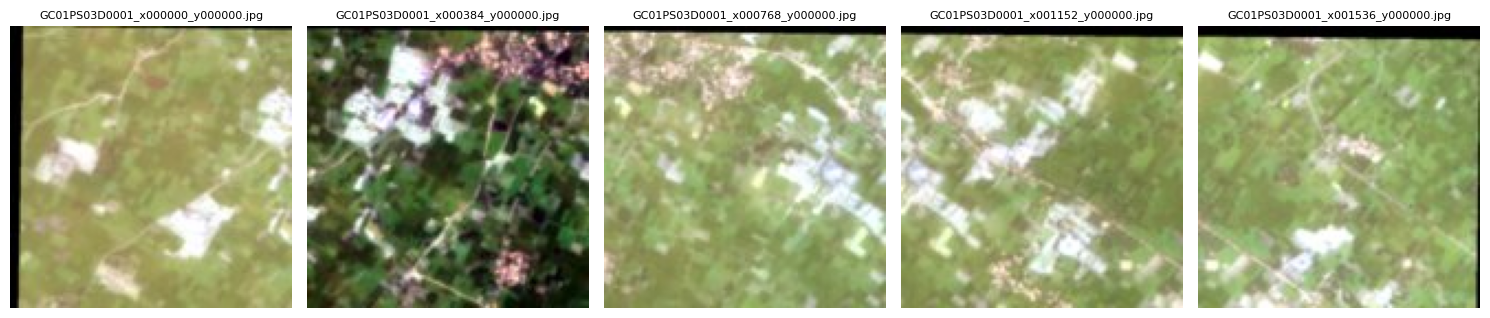


Sample rows (first 10):
                                 parent_image  \
0  data/raw/development-set/GC01PS03D0001.tif   
1  data/raw/development-set/GC01PS03D0001.tif   
2  data/raw/development-set/GC01PS03D0001.tif   
3  data/raw/development-set/GC01PS03D0001.tif   
4  data/raw/development-set/GC01PS03D0001.tif   
5  data/raw/development-set/GC01PS03D0001.tif   
6  data/raw/development-set/GC01PS03D0001.tif   
7  data/raw/development-set/GC01PS03D0001.tif   
8  data/raw/development-set/GC01PS03D0001.tif   
9  data/raw/development-set/GC01PS03D0001.tif   

                                       tile_path_tif  \
0  data/processed/tiles/GC01PS03D0001/GC01PS03D00...   
1  data/processed/tiles/GC01PS03D0001/GC01PS03D00...   
2  data/processed/tiles/GC01PS03D0001/GC01PS03D00...   
3  data/processed/tiles/GC01PS03D0001/GC01PS03D00...   
4  data/processed/tiles/GC01PS03D0001/GC01PS03D00...   
5  data/processed/tiles/GC01PS03D0001/GC01PS03D00...   
6  data/processed/tiles/GC01PS03D0001/GC01P

In [9]:
# Cell 1.8 - Repair tile_path_thumb in manifest by matching existing thumbnails (and preview samples)
# Purpose: Fix entries in tiles_manifest_full.parquet where tile_path_thumb points to missing files,
# by mapping to actual files in test/thumbnails_batched. Save fixed manifest to tiles_manifest_full_fixed.parquet and preview.

import os, glob, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

PROJECT_ROOT = "/gdrive/MyDrive/project_visual_search"
TEST_DIR = os.path.join(PROJECT_ROOT, "test")
MANIFEST_IN = os.path.join(TEST_DIR, "tiles_manifest_full.parquet")
MANIFEST_OUT = os.path.join(TEST_DIR, "tiles_manifest_full_fixed.parquet")
THUMBS_DIR = os.path.join(TEST_DIR, "thumbnails_batched")

# Load manifest
df = pd.read_parquet(MANIFEST_IN)
print("Loaded manifest rows:", len(df))

# Build basename -> fullpath map for thumbnails_batched
thumb_files = glob.glob(os.path.join(THUMBS_DIR, "*.jpg"))
print("Found thumbnails in thumbnails_batched:", len(thumb_files))
basename_map = {os.path.basename(p): p for p in thumb_files}

# Normalize existing tile_path_thumb values to basenames
def thumb_basename_from_row(row):
    tp = row.get("tile_path_thumb")
    if not tp or not isinstance(tp, str):
        return None
    return os.path.basename(tp)

# Count existing valid thumbnail paths in manifest
exists_mask = df["tile_path_thumb"].apply(lambda p: isinstance(p, str) and os.path.exists(p))
n_valid = exists_mask.sum()
n_total = len(df)
print(f"Manifest: {n_valid} thumbnails exist on disk, {n_total - n_valid} missing according to current paths.")

# Attempt to repair missing thumbnails by matching basename
fixed = 0
not_found = 0
new_paths = []

for idx, row in df.iterrows():
    cur = row.get("tile_path_thumb")
    if isinstance(cur, str) and os.path.exists(cur):
        new_paths.append(cur)
        continue
    # try matching by basename
    base = thumb_basename_from_row(row)
    if base and base in basename_map:
        new_paths.append(basename_map[base])
        fixed += 1
    else:
        # fallback: try to derive basename from tile_id if present
        tile_id = row.get("tile_id") or ""
        # some thumbnails use tile_id + '.jpg'
        candidate = f"{tile_id}.jpg"
        if candidate in basename_map:
            new_paths.append(basename_map[candidate])
            fixed += 1
        else:
            new_paths.append(None)
            not_found += 1

print(f"Fixed {fixed} missing thumbnail paths by matching existing files. Still missing: {not_found}")

# Update dataframe and save
df["tile_path_thumb_fixed"] = new_paths
df_out = df.copy()
# Replace original column with fixed where available (keep original if it's valid)
def choose_thumb(orig, fixedv):
    if isinstance(orig, str) and os.path.exists(orig):
        return orig
    return fixedv

df_out["tile_path_thumb"] = [choose_thumb(o, f) for o, f in zip(df["tile_path_thumb"], df_out["tile_path_thumb_fixed"])]
# drop helper column
df_out = df_out.drop(columns=["tile_path_thumb_fixed"])

# Write fixed manifest
df_out.to_parquet(MANIFEST_OUT, index=False)
print("Wrote fixed manifest to:", MANIFEST_OUT)

# Report remaining missing thumbnails
remaining_missing = df_out["tile_path_thumb"].isna().sum()
print("Remaining rows with no thumbnail:", remaining_missing)

# Preview 5 available thumbnails (first 5 rows that have valid thumbnail paths)
valid_rows = df_out[df_out["tile_path_thumb"].notna()].head(5)
if not valid_rows.empty:
    plt.figure(figsize=(15, 6))
    for i, (_, r) in enumerate(valid_rows.iterrows(), 1):
        tp = r["tile_path_thumb"]
        try:
            img = mpimg.imread(tp)
            plt.subplot(1, 5, i)
            plt.imshow(img)
            plt.axis("off")
            plt.title(os.path.basename(tp), fontsize=8)
        except Exception as e:
            print("Error loading thumbnail:", tp, e)
    plt.tight_layout()
    plt.show()
else:
    print("No thumbnails available to preview (all missing).")

# Print a small table of first 10 rows showing parent_image, tile_path_tif, tile_path_thumb
print("\nSample rows (first 10):")
print(df_out[["parent_image", "tile_path_tif", "tile_path_thumb"]].head(10))


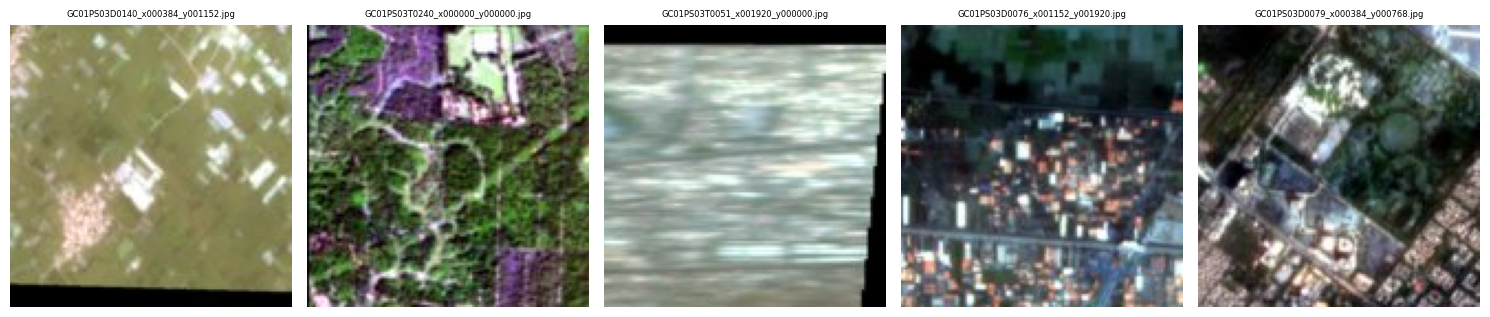

In [10]:
# Cell 1.9 - Display 5 random thumbnails from fixed manifest
# Purpose: Visual verification of repaired thumbnail paths

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

FINAL_FIXED = "/gdrive/MyDrive/project_visual_search/test/tiles_manifest_full_fixed.parquet"
df_fixed = pd.read_parquet(FINAL_FIXED)

# Pick 5 random rows
sample_rows = df_fixed.sample(5, random_state=123)

plt.figure(figsize=(15, 8))
for i, (_, row) in enumerate(sample_rows.iterrows(), 1):
    thumb_path = row["tile_path_thumb"]
    img = mpimg.imread(thumb_path)
    plt.subplot(1, 5, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(os.path.basename(thumb_path), fontsize=6)

plt.tight_layout()
plt.show()
